🚀 Running on: cpu
📦 Processing LA: 2250 images
📦 Processing HA: 2880 images
🕒 Training model...
Epoch 0 | Loss: 0.7923
Epoch 50 | Loss: 0.5546
Epoch 100 | Loss: 0.5336
Epoch 150 | Loss: 0.5166

      FINAL RESULTS      
              precision    recall  f1-score   support

         Low       0.54      0.69      0.60       450
        High       0.69      0.54      0.61       576

    accuracy                           0.61      1026
   macro avg       0.61      0.61      0.61      1026
weighted avg       0.62      0.61      0.61      1026

 ROC AUC Score: 0.6843


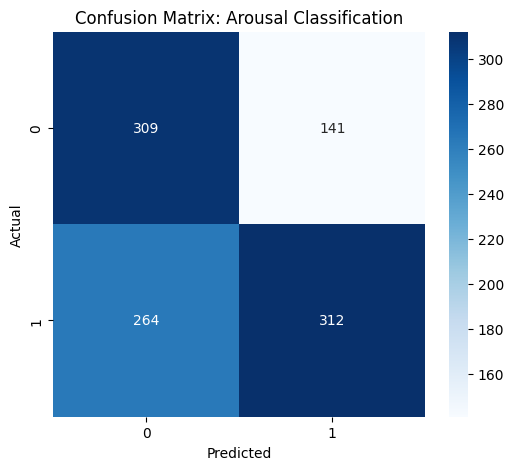

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_path = r"D:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Arousal_PR_2classes"
BATCH_SIZE = 32

print(f"🚀 Running on: {device}")


resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet.fc = nn.Identity()
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_and_extract():
    all_features, all_labels = [], []
    categories = {'LA': 0, 'HA': 1}
    
    for cat, label in categories.items():
        folder = os.path.join(base_path, cat)
        img_paths = glob.glob(os.path.join(folder, "*.*"))
        print(f"📦 Processing {cat}: {len(img_paths)} images")
        
        for i in range(0, len(img_paths), BATCH_SIZE):
            batch_files = img_paths[i : i + BATCH_SIZE]
            batch_tensors = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch_files]).to(device)
            
            with torch.no_grad():
                feats = resnet(batch_tensors).cpu()
                all_features.append(feats)
                all_labels.extend([label] * len(feats))
                
    x = torch.cat(all_features)
    y = torch.tensor(all_labels).long()
    
    
    indices = torch.randperm(len(x))
    split_at = int(0.8 * len(x))
    return x[indices[:split_at]], y[indices[:split_at]], x[indices[split_at:]], y[indices[split_at:]]

x_train, y_train, x_test, y_test = load_and_extract()


def create_knn_graph(x, k=10):
    distances = torch.cdist(x, x)
    _, nn_idx = distances.topk(k + 1, largest=False)
    source = torch.arange(nn_idx.size(0)).view(-1, 1).repeat(1, k).view(-1)
    target = nn_idx[:, 1:].reshape(-1)
    return torch.stack([source, target], dim=0)

train_graph = Data(x=x_train, edge_index=create_knn_graph(x_train)).to(device)
train_graph.y = y_train.to(device)
test_graph = Data(x=x_test, edge_index=create_knn_graph(x_test)).to(device)
test_graph.y = y_test.to(device)


class EmotionGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 256)
        self.bn1 = BatchNorm(256)
        self.conv2 = GCNConv(256, 2) 

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = EmotionGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)


print("🕒 Training model...")
model.train()
for epoch in range(151):
    optimizer.zero_grad()
    out = model(train_graph)
    loss = F.nll_loss(out, train_graph.y)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    logits = model(test_graph)
    preds = logits.argmax(dim=1).cpu().numpy()
    probs = torch.exp(logits)[:, 1].cpu().numpy()
    y_true = test_graph.y.cpu().numpy()

    print("\n" + "="*30)
    print("      FINAL RESULTS      ")
    print("="*30)
    print(classification_report(y_true, preds, target_names=['Low', 'High']))
    
    auc = roc_auc_score(y_true, probs)
    print(f" ROC AUC Score: {auc:.4f}")

    
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix: Arousal Classification")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

🚀 Running Fixed Dominance 2-Class on: cpu
📦 Processing LD: 970 images
📦 Processing HD: 4160 images
🕒 Training Balanced Dominance Model...
Epoch 0 | Loss: 1.1127
Epoch 50 | Loss: 0.5902
Epoch 100 | Loss: 0.5584
Epoch 150 | Loss: 0.5278
Epoch 200 | Loss: 0.5107
Epoch 250 | Loss: 0.4987
Epoch 300 | Loss: 0.4748

  DOMINANCE WEIGHTED REPORT   
              precision    recall  f1-score   support

         Low       0.26      0.34      0.30       199
        High       0.83      0.77      0.80       827

    accuracy                           0.69      1026
   macro avg       0.55      0.56      0.55      1026
weighted avg       0.72      0.69      0.70      1026

⭐ ROC AUC Score: 0.6408


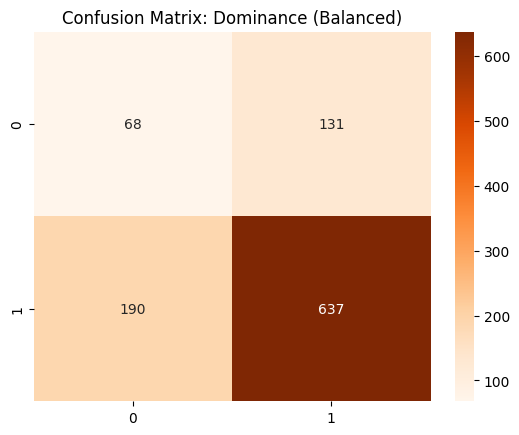

In [11]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_path = r"D:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_PR_2classes"
BATCH_SIZE = 32

print(f"🚀 Running Fixed Dominance 2-Class on: {device}")


resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet.fc = nn.Identity()
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_data():
    all_features, all_labels = [], []
    categories = {'LD': 0, 'HD': 1}
    for cat, label in categories.items():
        folder = os.path.join(base_path, cat)
        img_paths = glob.glob(os.path.join(folder, "*.*"))
        print(f"📦 Processing {cat}: {len(img_paths)} images")
        for i in range(0, len(img_paths), BATCH_SIZE):
            batch_files = img_paths[i : i + BATCH_SIZE]
            batch_tensors = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch_files]).to(device)
            with torch.no_grad():
                feats = resnet(batch_tensors).cpu()
                all_features.append(feats)
                all_labels.extend([label] * len(feats))
    x = torch.cat(all_features)
    y = torch.tensor(all_labels).long()
    indices = torch.randperm(len(x))
    split_at = int(0.8 * len(x))
    return x[indices[:split_at]], y[indices[:split_at]], x[indices[split_at:]], y[indices[split_at:]]

x_train, y_train, x_test, y_test = load_data()

def create_knn_graph(x, k=10):
    distances = torch.cdist(x, x)
    _, nn_idx = distances.topk(k + 1, largest=False)
    source = torch.arange(nn_idx.size(0)).view(-1, 1).repeat(1, k).view(-1)
    target = nn_idx[:, 1:].reshape(-1)
    return torch.stack([source, target], dim=0)

train_graph = Data(x=x_train, edge_index=create_knn_graph(x_train), y=y_train).to(device)
test_graph = Data(x=x_test, edge_index=create_knn_graph(x_test), y=y_test).to(device)

class DominanceGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 256)
        self.bn1 = BatchNorm(256)
        self.conv2 = GCNConv(256, 2)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = DominanceGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


class_weights = torch.tensor([4.3, 1.0]).to(device)

print("🕒 Training Balanced Dominance Model...")
model.train()
for epoch in range(301):
    optimizer.zero_grad()
    out = model(train_graph)
    loss = F.nll_loss(out, train_graph.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    logits = model(test_graph)
    preds = logits.argmax(dim=1).cpu().numpy()
    probs = torch.exp(logits)[:, 1].cpu().numpy()
    y_true = test_graph.y.cpu().numpy()

    print("\n" + "="*30)
    print("  DOMINANCE WEIGHTED REPORT   ")
    print("="*30)
    print(classification_report(y_true, preds, target_names=['Low', 'High']))
    print(f"⭐ ROC AUC Score: {roc_auc_score(y_true, probs):.4f}")

    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Oranges')
    plt.title("Confusion Matrix: Dominance (Balanced)")
    plt.show()

🚀 Running Valence 2-Class on: cpu
📦 Processing LV: 400 images
📦 Processing HV: 4720 images
🕒 Training Valence Model...
Epoch 0 | Loss: 0.9055
Epoch 50 | Loss: 0.5188
Epoch 100 | Loss: 0.4595
Epoch 150 | Loss: 0.4183
Epoch 200 | Loss: 0.3847
Epoch 250 | Loss: 0.3664
Epoch 300 | Loss: 0.3595

    VALENCE 2-CLASS REPORT    
                 precision    recall  f1-score   support

 Low (Negative)       0.08      0.47      0.14        77
High (Positive)       0.93      0.58      0.71       947

       accuracy                           0.57      1024
      macro avg       0.51      0.52      0.43      1024
   weighted avg       0.87      0.57      0.67      1024

⭐ ROC AUC Score: 0.5909


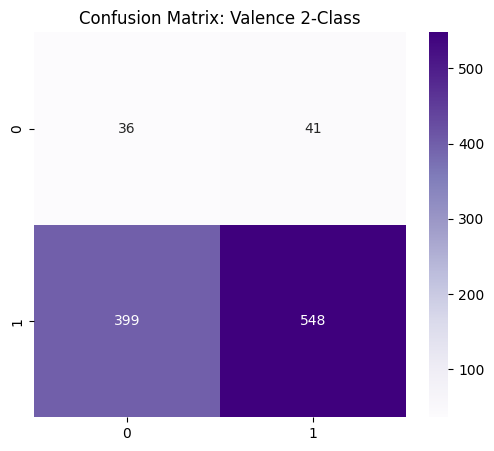

In [10]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"D:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_2classes"
BATCH_SIZE = 32

print(f"🚀 Running Valence 2-Class on: {device}")


resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet.fc = nn.Identity()
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_valence_data():
    all_features, all_labels = [], []
    categories = {'LV': 0, 'HV': 1} 
    
    for cat, label in categories.items():
        folder = os.path.join(base_path, cat)
        if not os.path.exists(folder):
            print(f"⚠️ Folder Missing: {folder}")
            continue
            
        img_paths = glob.glob(os.path.join(folder, "*.*"))
        print(f"📦 Processing {cat}: {len(img_paths)} images")
        
        for i in range(0, len(img_paths), BATCH_SIZE):
            batch_files = img_paths[i : i + BATCH_SIZE]
            batch_tensors = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch_files]).to(device)
            
            with torch.no_grad():
                feats = resnet(batch_tensors).cpu()
                all_features.append(feats)
                all_labels.extend([label] * len(feats))
                
    if not all_features:
        raise ValueError("❌ Images not found.")

    x = torch.cat(all_features)
    y = torch.tensor(all_labels).long()
    
    indices = torch.randperm(len(x))
    split_at = int(0.8 * len(x))
    return x[indices[:split_at]], y[indices[:split_at]], x[indices[split_at:]], y[indices[split_at:]]

x_train, y_train, x_test, y_test = load_valence_data()


def create_knn_graph(x, k=10):
    distances = torch.cdist(x, x)
    _, nn_idx = distances.topk(k + 1, largest=False)
    source = torch.arange(nn_idx.size(0)).view(-1, 1).repeat(1, k).view(-1)
    target = nn_idx[:, 1:].reshape(-1)
    return torch.stack([source, target], dim=0)

train_graph = Data(x=x_train, edge_index=create_knn_graph(x_train)).to(device)
train_graph.y = y_train.to(device)
test_graph = Data(x=x_test, edge_index=create_knn_graph(x_test)).to(device)
test_graph.y = y_test.to(device)


class ValenceGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 256)
        self.bn1 = BatchNorm(256)
        self.conv2 = GCNConv(256, 2) 

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = ValenceGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

class_weights = torch.tensor([11.8, 1.0]).to(device)


criterion = nn.NLLLoss(weight=class_weights)


print("🕒 Training Valence Model...")
model.train()
for epoch in range(301):
    optimizer.zero_grad()
    out = model(train_graph)
    loss = F.nll_loss(out, train_graph.y, weight=class_weights) 
    
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    logits = model(test_graph)
    preds = logits.argmax(dim=1).cpu().numpy()
    probs = torch.exp(logits)[:, 1].cpu().numpy()
    y_true = test_graph.y.cpu().numpy()

    print("\n" + "="*30)
    print("    VALENCE 2-CLASS REPORT    ")
    print("="*30)
    print(classification_report(y_true, preds, target_names=['Low (Negative)', 'High (Positive)']))
    
    auc = roc_auc_score(y_true, probs)
    print(f"⭐ ROC AUC Score: {auc:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Purples')
    plt.title("Confusion Matrix: Valence 2-Class")
    plt.show()

📦 Processing LD: 960 images
📦 Processing MD: 873 images
📦 Processing HD: 3280 images
🕒 Training Balanced Dominance 3-Class Model...
Epoch 0 | Loss: 1.5916
Epoch 50 | Loss: 0.9493
Epoch 100 | Loss: 0.9072
Epoch 150 | Loss: 0.8654
Epoch 200 | Loss: 0.8348
Epoch 250 | Loss: 0.8144
Epoch 300 | Loss: 0.7931

📊 3-Class Weighted Performance
              precision    recall  f1-score   support

         Low       0.23      0.13      0.16       190
         Mid       0.23      0.31      0.26       172
        High       0.68      0.71      0.70       661

    accuracy                           0.54      1023
   macro avg       0.38      0.38      0.38      1023
weighted avg       0.52      0.54      0.53      1023

⭐ Macro-Average ROC AUC Score: 0.6193


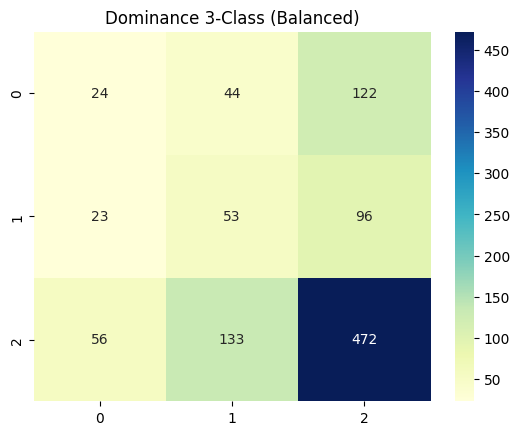

In [12]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_path = r"D:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Dominance_P_3Clases"
BATCH_SIZE = 32


resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet.fc = nn.Identity()
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_data():
    all_features, all_labels = [], []
    categories = {'LD': 0, 'MD': 1, 'HD': 2}
    for cat, label in categories.items():
        folder = os.path.join(base_path, cat)
        img_paths = glob.glob(os.path.join(folder, "*.*"))
        print(f"📦 Processing {cat}: {len(img_paths)} images")
        for i in range(0, len(img_paths), BATCH_SIZE):
            batch_files = img_paths[i : i + BATCH_SIZE]
            batch_tensors = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch_files]).to(device)
            with torch.no_grad():
                feats = resnet(batch_tensors).cpu()
                all_features.append(feats)
                all_labels.extend([label] * len(feats))
    x = torch.cat(all_features)
    y = torch.tensor(all_labels).long()
    indices = torch.randperm(len(x))
    split_at = int(0.8 * len(x))
    return x[indices[:split_at]], y[indices[:split_at]], x[indices[split_at:]], y[indices[split_at:]]

x_train, y_train, x_test, y_test = load_data()


def create_knn_graph(x, k=10):
    distances = torch.cdist(x, x)
    _, nn_idx = distances.topk(k + 1, largest=False)
    source = torch.arange(nn_idx.size(0)).view(-1, 1).repeat(1, k).view(-1)
    target = nn_idx[:, 1:].reshape(-1)
    return torch.stack([source, target], dim=0)

train_graph = Data(x=x_train, edge_index=create_knn_graph(x_train), y=y_train).to(device)
test_graph = Data(x=x_test, edge_index=create_knn_graph(x_test), y=y_test).to(device)

class Dominance3GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 256)
        self.bn1 = BatchNorm(256)
        self.conv2 = GCNConv(256, 3) 
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = Dominance3GNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

class_weights = torch.tensor([3.4, 3.8, 1.0]).to(device)

print("🕒 Training Balanced Dominance 3-Class Model...")
model.train()
for epoch in range(301):
    optimizer.zero_grad()
    out = model(train_graph)
    loss = F.nll_loss(out, train_graph.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    logits = model(test_graph)
    probs = torch.exp(logits).cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()
    y_true = test_graph.y.cpu().numpy()

  
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    macro_auc = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')

    print("\n📊 3-Class Weighted Performance")
    print(classification_report(y_true, preds, target_names=['Low', 'Mid', 'High']))
    print(f"⭐ Macro-Average ROC AUC Score: {macro_auc:.4f}")

    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='YlGnBu')
    plt.title("Dominance 3-Class (Balanced)")
    plt.show()

📦 Processing LV: 280 images
📦 Processing MV: 560 images
📦 Processing HV: 4280 images
🕒 Training Balanced Valence 3-Class Model...
Epoch 0 | Loss: 1.4221
Epoch 50 | Loss: 0.9006
Epoch 100 | Loss: 0.7844
Epoch 150 | Loss: 0.7098
Epoch 200 | Loss: 0.6720
Epoch 250 | Loss: 0.6019
Epoch 300 | Loss: 0.5672

📊 Valence 3-Class Balanced Report
              precision    recall  f1-score   support

         Low       0.04      0.02      0.03        51
         Mid       0.14      0.66      0.23       118
        High       0.88      0.45      0.60       855

    accuracy                           0.45      1024
   macro avg       0.35      0.38      0.28      1024
weighted avg       0.76      0.45      0.53      1024

⭐ Macro-Average ROC AUC Score: 0.6042


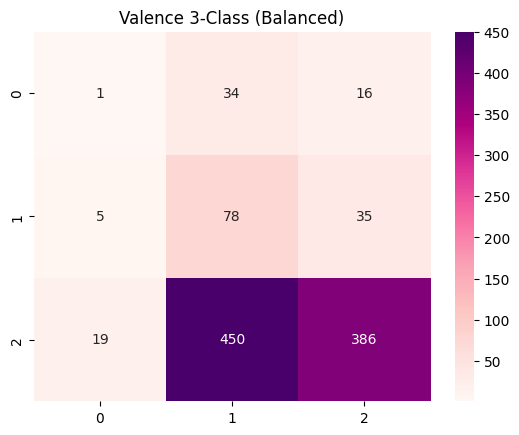

In [13]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_path = r"D:\DEAP_Dimensional Data_N\DEAP_Dimensional Data\Valence_PR_3classes"
BATCH_SIZE = 32


resnet = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet.fc = nn.Identity()
resnet.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_data():
    all_features, all_labels = [], []
    categories = {'LV': 0, 'MV': 1, 'HV': 2}
    for cat, label in categories.items():
        folder = os.path.join(base_path, cat)
        img_paths = glob.glob(os.path.join(folder, "*.*"))
        print(f"📦 Processing {cat}: {len(img_paths)} images")
        for i in range(0, len(img_paths), BATCH_SIZE):
            batch_files = img_paths[i : i + BATCH_SIZE]
            batch_tensors = torch.stack([preprocess(Image.open(p).convert('RGB')) for p in batch_files]).to(device)
            with torch.no_grad():
                feats = resnet(batch_tensors).cpu()
                all_features.append(feats)
                all_labels.extend([label] * len(feats))
    x = torch.cat(all_features)
    y = torch.tensor(all_labels).long()
    indices = torch.randperm(len(x))
    split_at = int(0.8 * len(x))
    return x[indices[:split_at]], y[indices[:split_at]], x[indices[split_at:]], y[indices[split_at:]]

x_train, y_train, x_test, y_test = load_data()


def create_knn_graph(x, k=10):
    distances = torch.cdist(x, x)
    _, nn_idx = distances.topk(k + 1, largest=False)
    source = torch.arange(nn_idx.size(0)).view(-1, 1).repeat(1, k).view(-1)
    target = nn_idx[:, 1:].reshape(-1)
    return torch.stack([source, target], dim=0)

train_graph = Data(x=x_train, edge_index=create_knn_graph(x_train), y=y_train).to(device)
test_graph = Data(x=x_test, edge_index=create_knn_graph(x_test), y=y_test).to(device)

class Valence3GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 256)
        self.bn1 = BatchNorm(256)
        self.conv2 = GCNConv(256, 3) 
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        return F.log_softmax(self.conv2(x, edge_index), dim=1)

model = Valence3GNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


class_weights = torch.tensor([15.0, 7.5, 1.0]).to(device)

print("🕒 Training Balanced Valence 3-Class Model...")
model.train()
for epoch in range(301):
    optimizer.zero_grad()
    out = model(train_graph)
    loss = F.nll_loss(out, train_graph.y, weight=class_weights)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    logits = model(test_graph)
    probs = torch.exp(logits).cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()
    y_true = test_graph.y.cpu().numpy()

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    macro_auc = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')

    print("\n📊 Valence 3-Class Balanced Report")
    print(classification_report(y_true, preds, target_names=['Low', 'Mid', 'High']))
    print(f"⭐ Macro-Average ROC AUC Score: {macro_auc:.4f}")

    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='RdPu')
    plt.title("Valence 3-Class (Balanced)")
    plt.show()